# Study 852 — Movie-Sequel Fatigue — for the quants 🔬

The full battery: the raw vs franchise-FE fatigue slope, the two-era robustness cut, a sequel-number label-permutation placebo, a random-date placebo, the within-franchise AR(1) persistence, a costed short-the-tired-sequel leg, and a 20-seed synthetic positive control. Everything offline once cached; fingerprint `5a2c01b12a9b`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sequel_fatigue import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching DIS + CMCSA + PARA + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
cars = st.build_event_cars(prices)
inc = cars[cars["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} franchise entries resolved")


panel loaded; 43 of 46 franchise entries resolved


## 1. The mean reaction + the fatigue slope (H1)

Each film reduces to one number: the studio's abnormal return (studio − SPY) over `[anchor−1 .. anchor+3]`. The unit is a cross-event *t* (independent releases), and the fatigue slope is an OLS of CAR on sequel number — raw, then with a franchise fixed effect (the *within*-franchise tilt).

In [2]:
d0 = st.day0_stats(inc, 'car')
print(f'mean CAR {d0["mean"]*100:+.3f}%  t={d0["t"]:+.3f}  NW-t={d0["t_nw"]:+.3f}  up {d0["up_k"]}/{d0["up_n"]}')
for label, dem in [('raw', False), ('franchise-FE', True)]:
    s = st.fatigue_slope(inc, demean=dem)
    print(f'{label:<12s} slope={s["slope"]*100:+.4f}%/seq  t={s["t"]:+.3f}  r={s["r"]:+.3f}')

mean CAR -0.734%  t=-1.831  NW-t=-2.056  up 17/43
raw          slope=-0.2157%/seq  t=-1.196  r=-0.184
franchise-FE slope=-0.9023%/seq  t=-3.054  r=-0.430


## 2. Two-era robustness — the fixed-effect slope is a post-2018 artifact

A 'Real' stamp needs the sign to hold across sub-eras. It does not: the within-franchise slope is a dead ~−0.95 *t* before 2018 and an implausibly tight −8.9 *t* after (a few 2-entry franchises).

In [3]:
era = st.era_slopes(inc, demean=True)
for k in ('early','late'):
    e = era[k]; print(f'{k:<6s} n={e["n"]:2d}  slope={e["slope"]*100:+.4f}%/seq  t={e["t"]:+.3f}  r={e["r"]:+.3f}')

early  n=25  slope=-0.4047%/seq  t=-0.952  r=-0.195
late   n=18  slope=-3.5040%/seq  t=-8.853  r=-0.911


## 3. Placebo A — permute the sequel-number labels (H1 falsification)

Shuffle the sequel numbers across events (breaking any seq→CAR link) and recompute the slope. The franchise-FE slope is outside the shuffle cloud (a real *within*-franchise ordering); the **raw** slope sits comfortably inside it — the significance lives only in the fixed-effect specification. (Shown live at 1,500 draws; docs/results.md uses 5,000 → raw p_two = 0.24.)

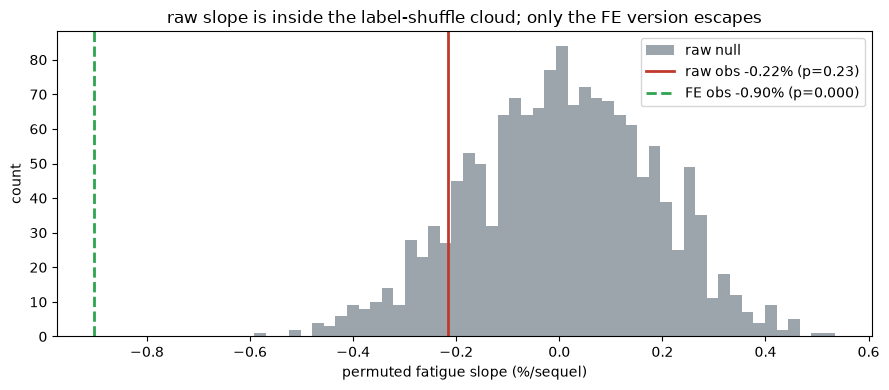

raw: {'obs_slope': -0.0022, 'placebo_mean': 0.0001, 'placebo_sd': 0.0018, 'p_two': 0.2327, 'p_left': 0.1107}


In [4]:
pl = st.permute_slope_pvalue(inc, demean=True, n_perm=1500)
plr = st.permute_slope_pvalue(inc, demean=False, n_perm=1500)
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(plr['draws']*100, bins=50, color='#8b949e', alpha=0.85, label='raw null')
ax.axvline(plr['obs_slope']*100, color='#c0392b', lw=2, label=f"raw obs {plr['obs_slope']*100:+.2f}% (p={plr['p_two']:.2f})")
ax.axvline(pl['obs_slope']*100, color='#2ea44f', lw=2, ls='--', label=f"FE obs {pl['obs_slope']*100:+.2f}% (p={pl['p_two']:.3f})")
ax.set_xlabel('permuted fatigue slope (%/sequel)'); ax.set_ylabel('count')
ax.set_title('raw slope is inside the label-shuffle cloud; only the FE version escapes'); ax.legend()
plt.tight_layout(); plt.show()
print('raw:', {k: round(v,4) for k,v in plr.items() if isinstance(v,float)})

## 4. Placebo B — random pseudo-event dates

For each event draw a random, non-event same-length window on the SAME studio ticker vs SPY. If the observed mean CAR is inside this cloud, the sequel reactions are indistinguishable from random dates.

In [5]:
rd = st.random_date_placebo(prices, inc, n_seeds=10, n_draws_per_seed=200)
print(f"observed mean CAR {rd['obs']*100:+.3f}%  vs random-window mean {rd['placebo_mean']*100:+.3f}% "
      f"(sd {rd['placebo_sd']*100:.3f}%)  p_two = {rd['p_two']:.3f}  over {rd['n_draws']:,} draws")

observed mean CAR -0.734%  vs random-window mean -0.086% (sd 0.477%)  p_two = 0.113  over 2,000 draws


## 5. Persistence (H2) — does a down sequence drag the next?

Within each franchise, pair consecutive entries and (a) regress N's CAR on N-1's CAR, (b) split N's CAR by whether N-1 was down. Both point the right way; both are insignificant (AR(1) *t* = +0.81, down-vs-up Welch *t* = -1.36).

In [6]:
per = st.fatigue_persistence(inc)
print(f'pairs={per["n_pairs"]}  AR(1) slope={per["ar1_slope"]:+.4f}  t={per["ar1_t"]:+.3f}')
print(f'next-CAR | prev-down {per["down_mean"]*100:+.3f}% (n={per["n_down"]})  vs  prev-up {per["up_mean"]*100:+.3f}% (n={per["n_up"]})  Welch t={per["welch_t"]:+.3f}')

pairs=29  AR(1) slope=+0.1463  t=+0.810
next-CAR | prev-down -1.927% (n=14)  vs  prev-up -0.730% (n=15)  Welch t=-1.364


## 6. Tradability — the short-the-fatigued-sequel leg, net of costs

Short the studio at the anchor of an entry whose predecessor reacted negatively; hold the reaction window. It *nominally* clears costs — but it fires **14 times in 20 years**, is conditioned in-sample on the (insignificant) persistence above, and lives in the same post-2018 window. What the *t* really tests is 'these 14 entries dipped', which Placebo B already puts inside the noise. **Fragile, not deployable.**

In [7]:
for c in (5.0, 10.0):
    tm = st.fatigue_timer(inc, cost_bps=c)
    print(f'@{c:>4.0f}bps  n={tm["n"]}  gross {tm["gross_mean"]*100:+.3f}% (t={tm["t_gross"]:+.2f})  net {tm["net_mean"]*100:+.3f}% (t={tm["t_net"]:+.2f})  [cost {tm["cost_bps"]:.1f} bps/rt]')

@   5bps  n=14  gross +1.927% (t=+2.95)  net +1.821% (t=+2.79)  [cost 10.5 bps/rt]
@  10bps  n=14  gross +1.927% (t=+2.95)  net +1.721% (t=+2.63)  [cost 20.5 bps/rt]


## 7. Synthetic positive control — the detector works, the null is quiet

The fatigue-slope detector must stay quiet on a planted-null world and recover a planted fatigue slope monotonically. At ~41 events with a franchise fixed effect the slope *t* is noisy — which frames why the real, shallow tilt shows up only as a whiff.

null: mean slope-t=-0.01 sd=1.25  |t|>=2 in 2/20


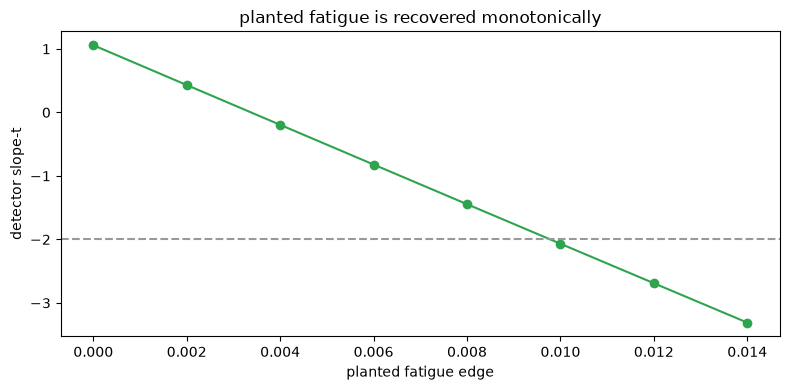

In [8]:
null_t = np.array([st.synthetic_detect(edge=0.0, seed=852+s)['t'] for s in range(20)])
print(f'null: mean slope-t={null_t.mean():+.2f} sd={null_t.std(ddof=1):.2f}  |t|>=2 in {(np.abs(null_t)>=2).sum()}/20')
edges = np.linspace(0, 0.014, 8)
ts = [st.synthetic_detect(edge=e, seed=852)['t'] for e in edges]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(edges, ts, 'o-', color='#2ea44f')
ax.axhline(-2, color='0.6', ls='--'); ax.set_xlabel('planted fatigue edge'); ax.set_ylabel('detector slope-t')
ax.set_title('planted fatigue is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: Weak.** The fatigue slope points the folklore's way but is insignificant raw (*t* = −1.20), significant only with a franchise fixed effect (*t* = −3.05) that lives entirely post-2018 (early *t* = −0.95 vs late *t* = −8.85, failing the cross-era bar), the mean reaction is inside the random-date cloud (p = 0.11), and persistence is insignificant. **Tradability: Fragile.** The short nominally clears costs (14 fires, +1.82% net @ 5 bps, *t* = 2.79) but rests on in-sample conditional selection of an insignificant persistence signal in a recent-era window — it will not survive out of sample.